In [4]:
import sys
sys.path.append('../')

from src.run_app import *
from src.prepare_gam import *
from src.utils import *
from src.rset_opt import *
from FasterRisk.src.fasterrisk import fasterrisk
from gam_rs_utils.binarize_dataset import binarize_dataset
from gam_rs_utils.utils import *

from time import time

In [7]:
for dname, settings in dataset_settings:
    path = f"../datasets/{dname}.csv"
    n_estimators = settings["num_estimators"]
    X_new, y, header_new, sample_p = get_binned_dataset(path, n_estimators)
    print(X_new.shape, y.shape)

(4521, 25) (4521,)
(6907, 22) (6907,)
(768, 50) (768,)
(4601, 30) (4601,)
(24508, 33) (24508,)


### Comparison

In [5]:
methods = [
    "uniform_ellipsoid_sampling",
    "poisson_False_ellipsoid_sampling",
    "poisson_True_ellipsoid_sampling",
    "permutation_False_ellipsoid_sampling",
    "permutation_True_ellipsoid_sampling",
    "blocking",
    "quadratic_programming",
    "swapping",
]
dataset_names = ["bank", "compas", "diabetes", "spambase", "mimic2"]

In [6]:
all_datasets_results = {}

for dname in dataset_names:
    all_columns = set()
    method_dfs = {}
    for method in methods:
        with open(f"../analysis/results/methods/{method}.pkl", "rb") as f:
            results = pickle.load(f)
        df = pd.DataFrame(results)
        df = df[df["dataset"] == dname]
        method_dfs[method] = df
        all_columns.update(df.columns)
    all_columns = list(all_columns)

    dfs = []
    for method, df in method_dfs.items():
        df = df.reindex(columns=all_columns)
        df["method"] = method
        dfs.append(df)
    combined_df = pd.concat(dfs, ignore_index=True)
    all_datasets_results[dname] = combined_df

In [ ]:
for dname, df in all_datasets_results.items():
    accuracy, logistic, hamming, iou, euclidean, cosine = [], [], [], [], [], []
    model_count, header = [], []
    for i, row in df.iterrows():
        path = f"../datasets/{dname}.csv"
        X, y, new_header, sample_p = get_binned_dataset(path, row["n_estimators"])
        w_rset = row["w_rset"]
        w_opt = row["w_opt"]
        predictions = row["predictions"]
        l2 = 0.001

        if w_rset.shape[0] == 0:
            accuracy.append(0)
            logistic.append(0)
            hamming.append(0)
            iou.append(0)
            euclidean.append(0)
            cosine.append(0)
            model_count.append(0)
            header.append(new_header)
            continue

        accuracy.append(get_loss(X, y, w_rset, loss_type="accuracy"))
        logistic.append(get_loss(X, y, w_rset, loss_type="logistic", l2=l2, sample_p=sample_p))
        hamming.append(average_pairwise_diversity(predictions.T, hamming_distance, limit=10))

        iou.append(average_pairwise_diversity(w_rset, inverse_IoU, limit=10))
        euclidean.append(average_pairwise_diversity(w_rset, euclidean_distance, limit=10))
        cosine.append(average_pairwise_diversity(w_rset, inverse_cosine_similarity, limit=10))
        model_count.append(w_rset.shape[0])
        header.append(new_header)

    df['accuracy'] = accuracy
    df['logistic'] = logistic
    df['hamming'] = hamming
    df['iou'] = iou
    df['euclidean'] = euclidean
    df['cosine'] = cosine
    df['model_count'] = model_count
    df['header'] = header

In [26]:
for dname, settings in dataset_settings[:1]:
    l0 = settings["l0"]
    l2 = settings["l2"]
    m = settings["m"]
    ne = settings["num_estimators"]
    binned = True

    filepath = f"../models/{dname}_{l0}_{l2}_{m}_{binned}.p"
    with open(filepath, "rb") as f:
        sparse_gam = pickle.load(f)
    print(dname, sparse_gam['rset_bound'])

bank 0.28041552941687936


In [27]:
dataset_results = all_datasets_results['bank']
X = sparse_gam['X']
y = sparse_gam['y']
sample_p = sparse_gam['sample_proportion']
opt_betas = dataset_results['opt_betas'].iloc[4]
opt_beta0 = dataset_results['opt_beta0'].iloc[4]
l2 = dataset_results['l2']

print(utils.get_log_loss(X, y, opt_betas, l2, sample_p))
print(get_loss_one_model(X, y, opt_beta0, opt_betas, "logistic", l2))

KeyError: 'opt_betas'

In [28]:
def show_loss_distributions(all_datasets_results, dname, loss_type):
    df = all_datasets_results[dname]
    for i, row in df.iterrows():
        path = f"../datasets/{dname}.csv"
        X, y, header, sample_p = get_binned_dataset(path, row["n_estimators"])
        w_rset = row['w_rset']
        w_opt = row['w_opt']
        l2 = row['l2']
        print(f"METHOD: {row['method']}")
        get_loss(
            X, y,
            w_rset,
            loss_type=loss_type,
            verbosity=1,
            w_opt=w_opt,
            l2=l2,
            sample_p=sample_p,
        )

def show_bar_plot(all_datasets_results, dname, metric):
    df = all_datasets_results[dname]
    plot_two_var_bar(df, "method", metric)

def show_gam(all_datasets_results, dname):
    df = all_datasets_results[dname]
    for i, row in df.iterrows():
        if row['model_count'] == 0:
            continue
        print(f"method: {row['method']}")
        plot_gam(np.array(row['header'][1:]), row['w_rset'][:, 1:])

def show_variable_importance(all_datasets_results, dname):
    df = all_datasets_results[dname]
    for i, row in df.iterrows():
        if row['model_count'] == 0:
            continue
        print(f"method: {row['method']}")

        path = f"../datasets/{dname}.csv"
        X, y, header, sample_p = get_binned_dataset(path, row["n_estimators"])
        w_rset = row['w_rset'][:, 1:]

        feature_to_vi = get_variable_importance(X, w_rset, np.array(header[1:]), True)
        plot_variable_importance(feature_to_vi)


METHOD: uniform_ellipsoid_sampling
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21] 0.6041342092051172


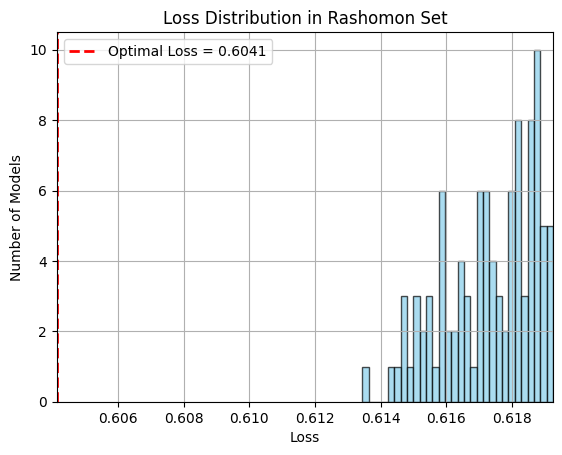

METHOD: poisson_False_ellipsoid_sampling
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21] 0.6041344177008384


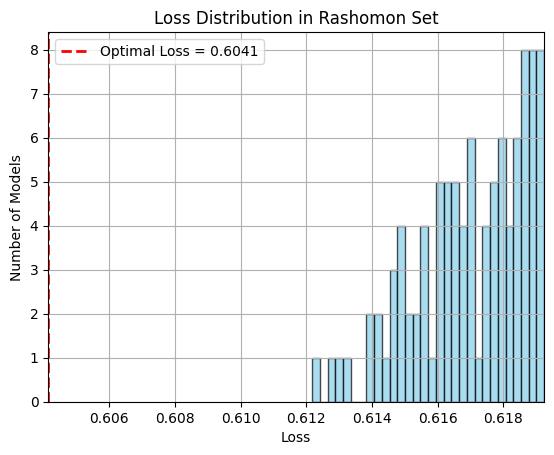

METHOD: poisson_True_ellipsoid_sampling
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21] 0.6041324885174244


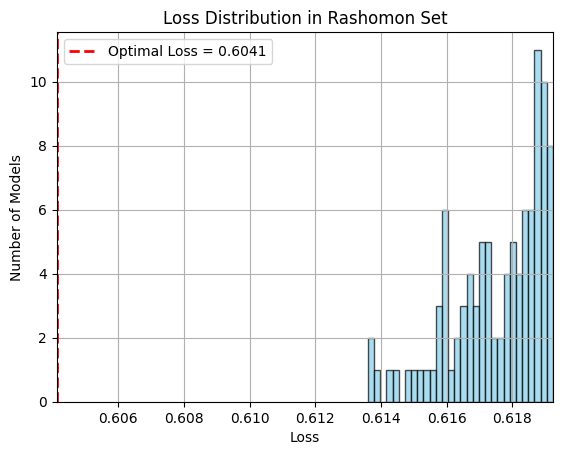

METHOD: permutation_False_ellipsoid_sampling
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21] 0.6041351315608443


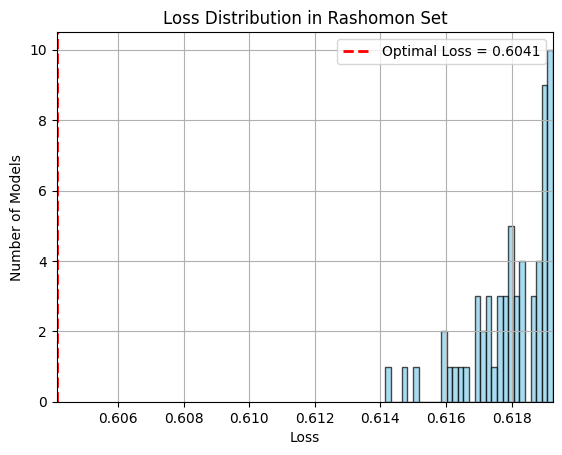

METHOD: permutation_True_ellipsoid_sampling
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21] 0.6041329507560111


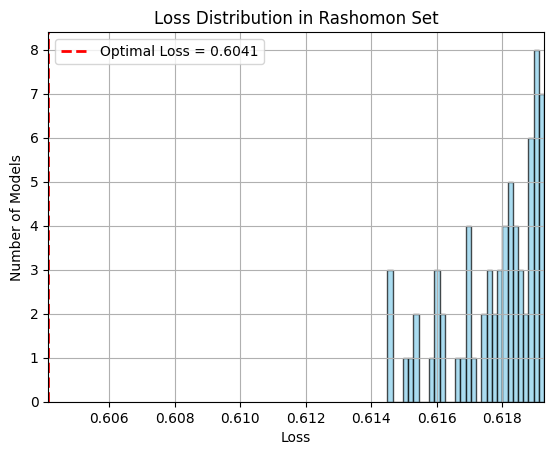

METHOD: blocking
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21] 0.6041313633512673


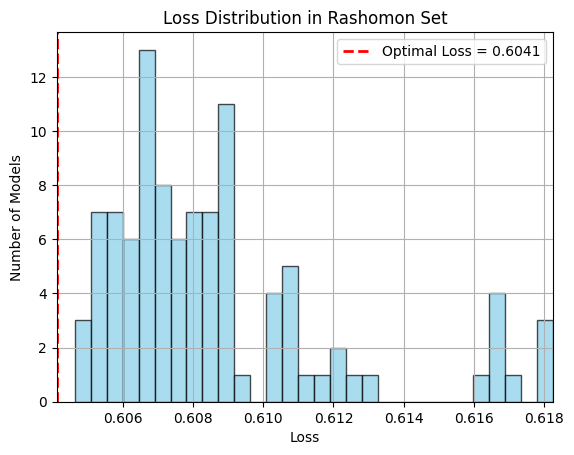

METHOD: quadratic_programming
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21] 0.6041348363728802


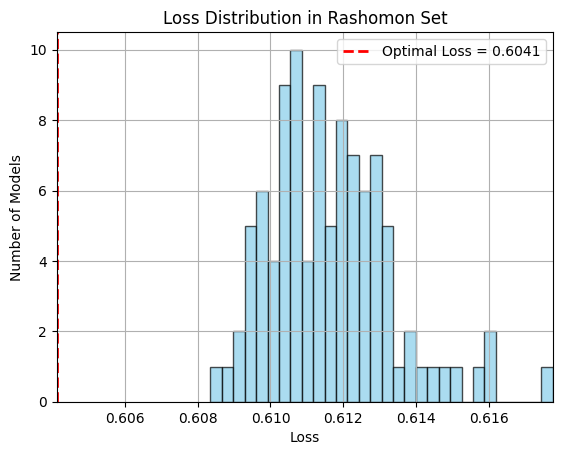

METHOD: swapping
optimal model
[ 0  1  2  3  4  5  6  7 12 13 14 15 16 17 18 19] 0.6023979724701976


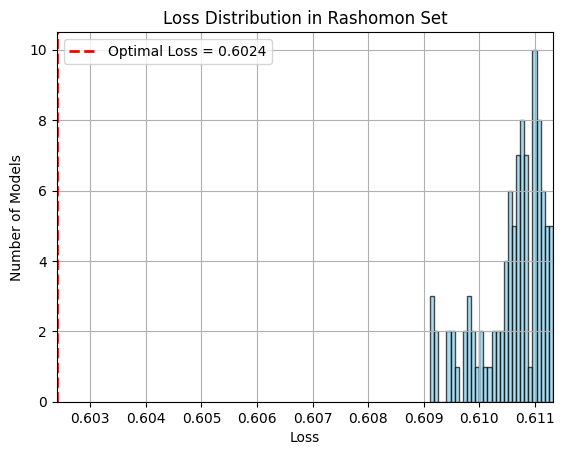

In [ ]:
show_loss_distributions(all_datasets_results, "compas", "logistic")

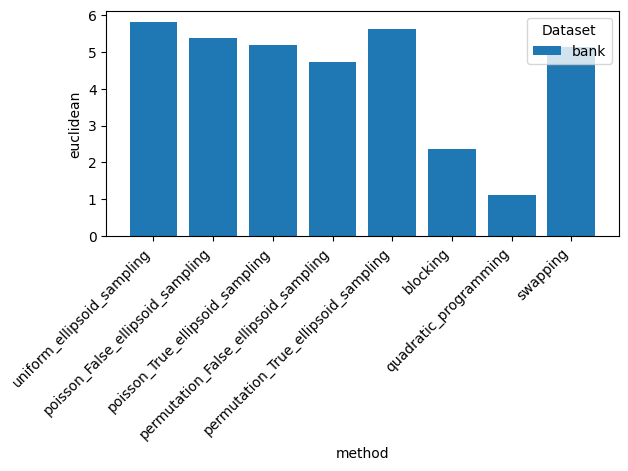

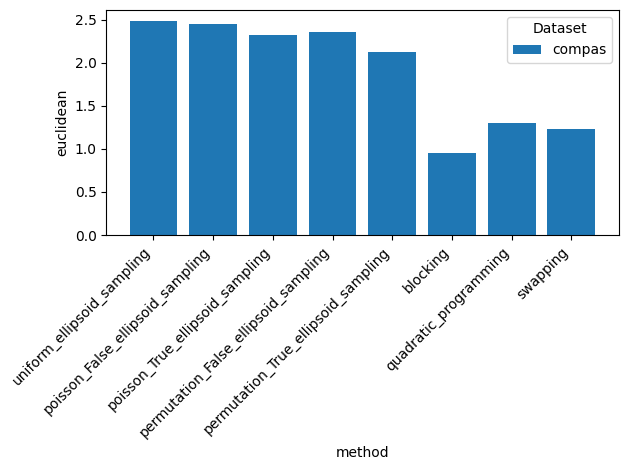

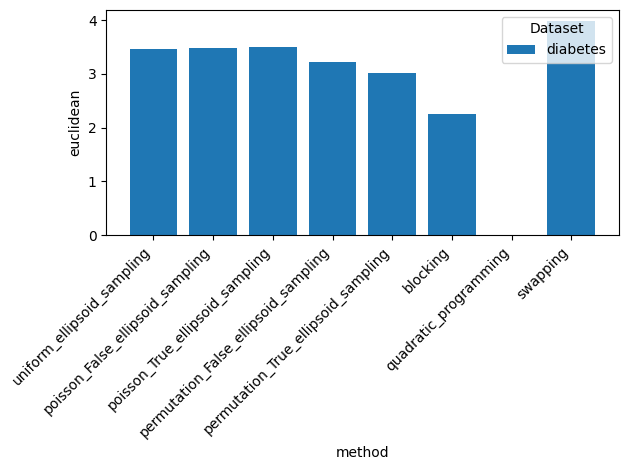

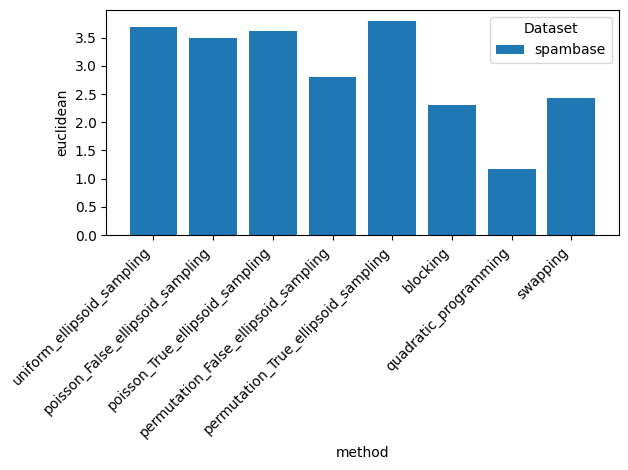

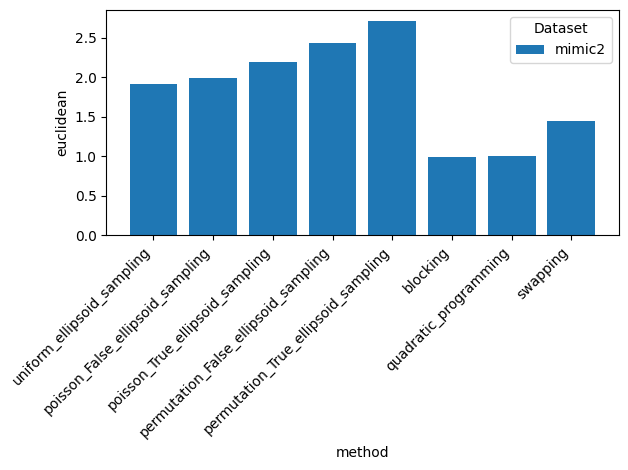

In [ ]:
for dname in dataset_names:
    show_bar_plot(all_datasets_results, dname, "cosine")

method: uniform_ellipsoid_sampling


100%|██████████| 100/100 [00:00<00:00, 12557.80it/s]


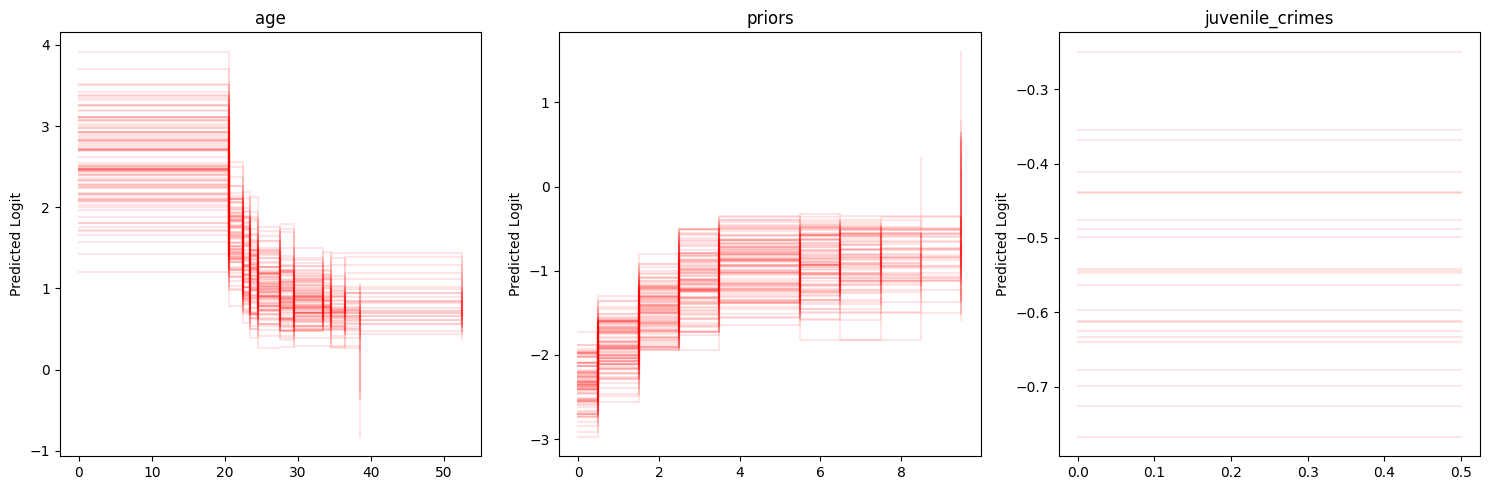

method: poisson_False_ellipsoid_sampling


100%|██████████| 100/100 [00:00<00:00, 15368.25it/s]


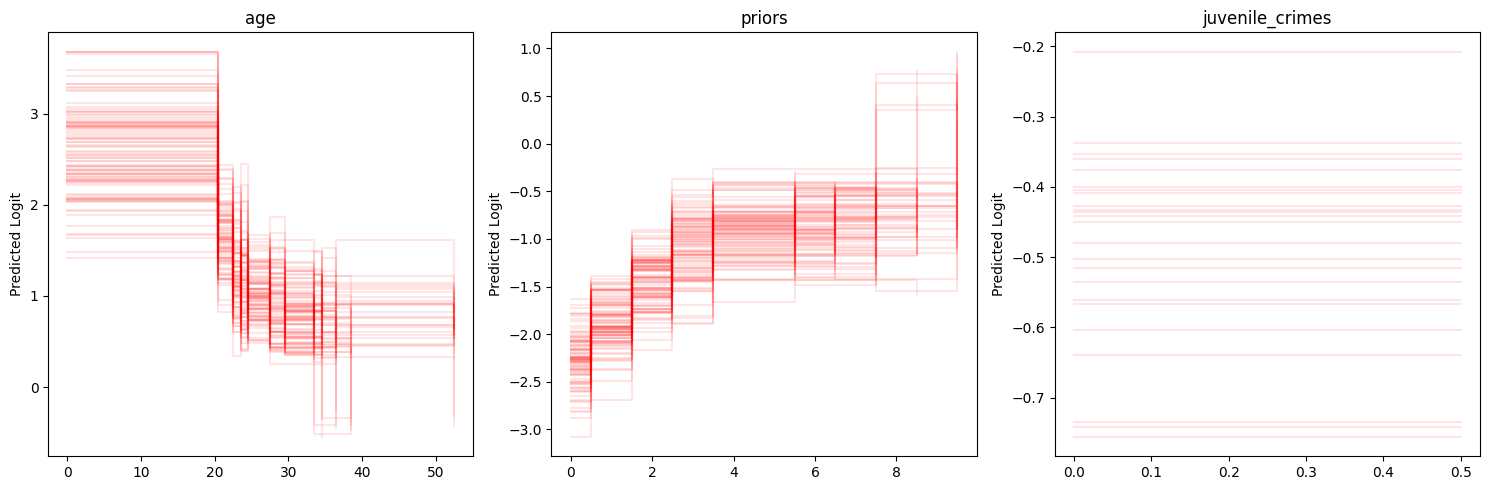

method: poisson_True_ellipsoid_sampling


100%|██████████| 100/100 [00:00<00:00, 15176.41it/s]


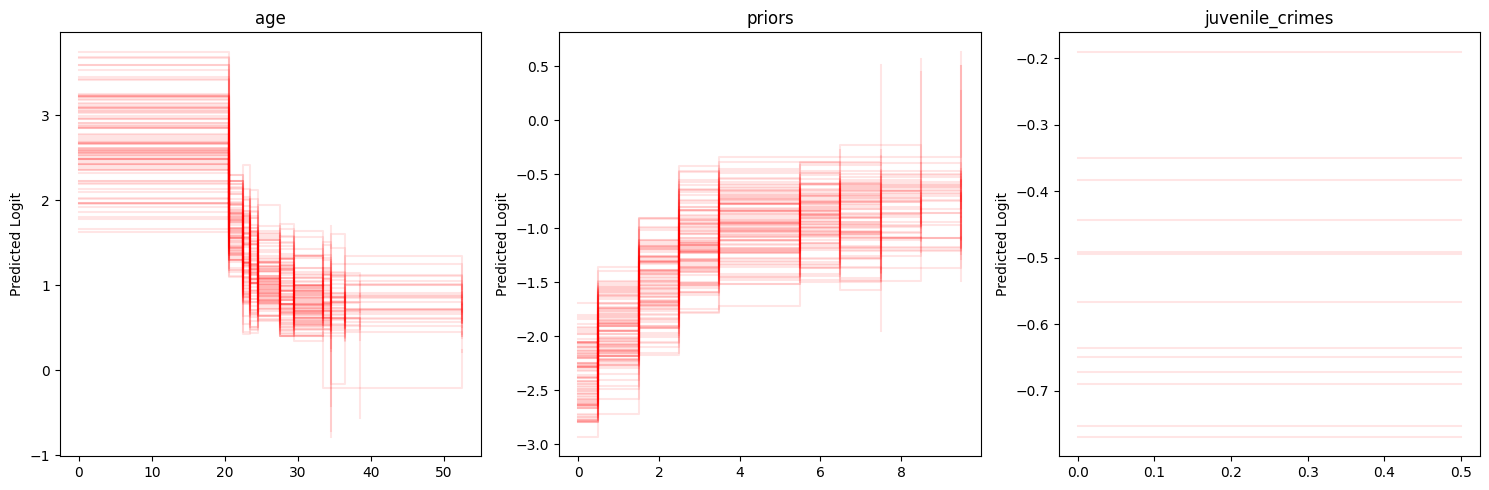

method: permutation_False_ellipsoid_sampling


100%|██████████| 62/62 [00:00<00:00, 14608.55it/s]


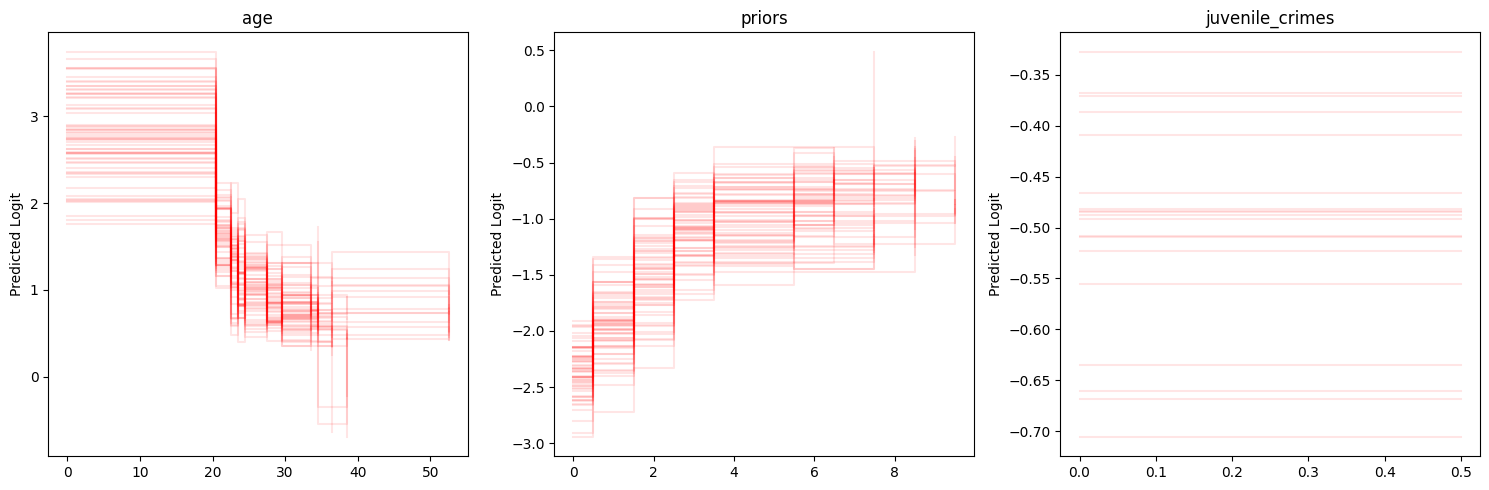

method: permutation_True_ellipsoid_sampling


100%|██████████| 69/69 [00:00<00:00, 5011.90it/s]


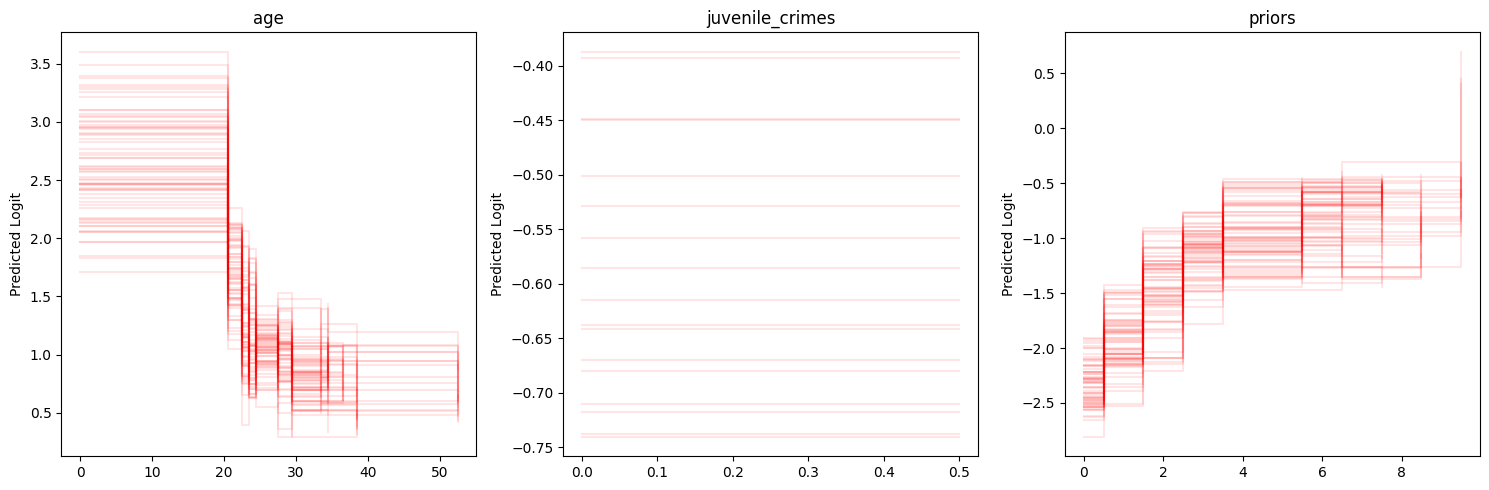

method: blocking


100%|██████████| 100/100 [00:00<00:00, 11866.75it/s]


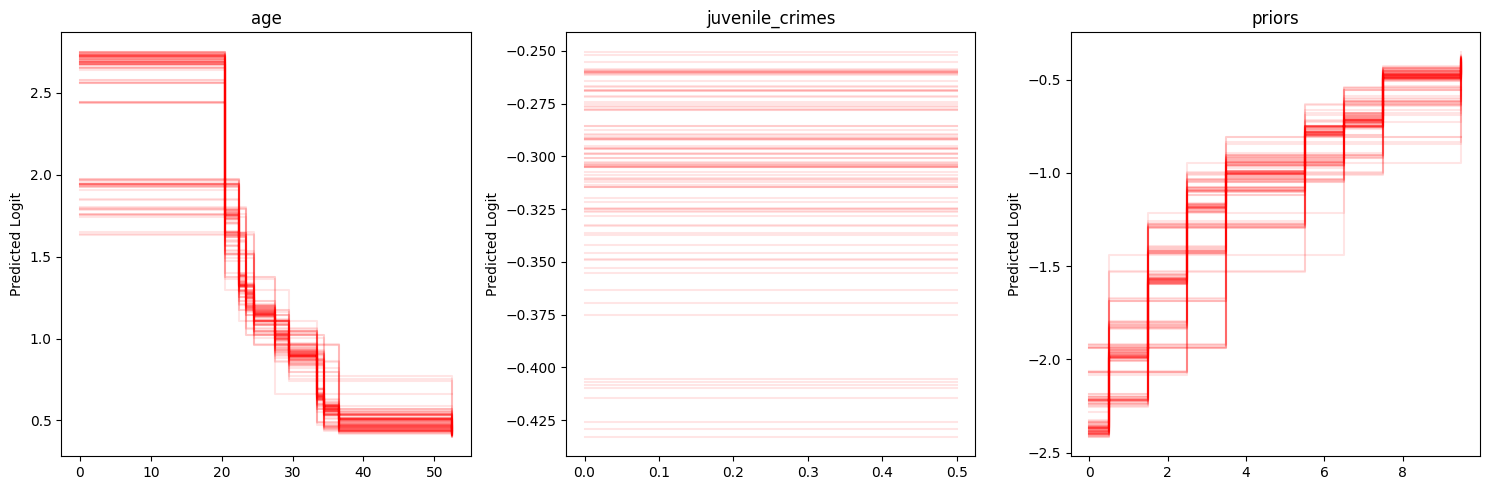

method: quadratic_programming


100%|██████████| 100/100 [00:00<00:00, 16460.52it/s]


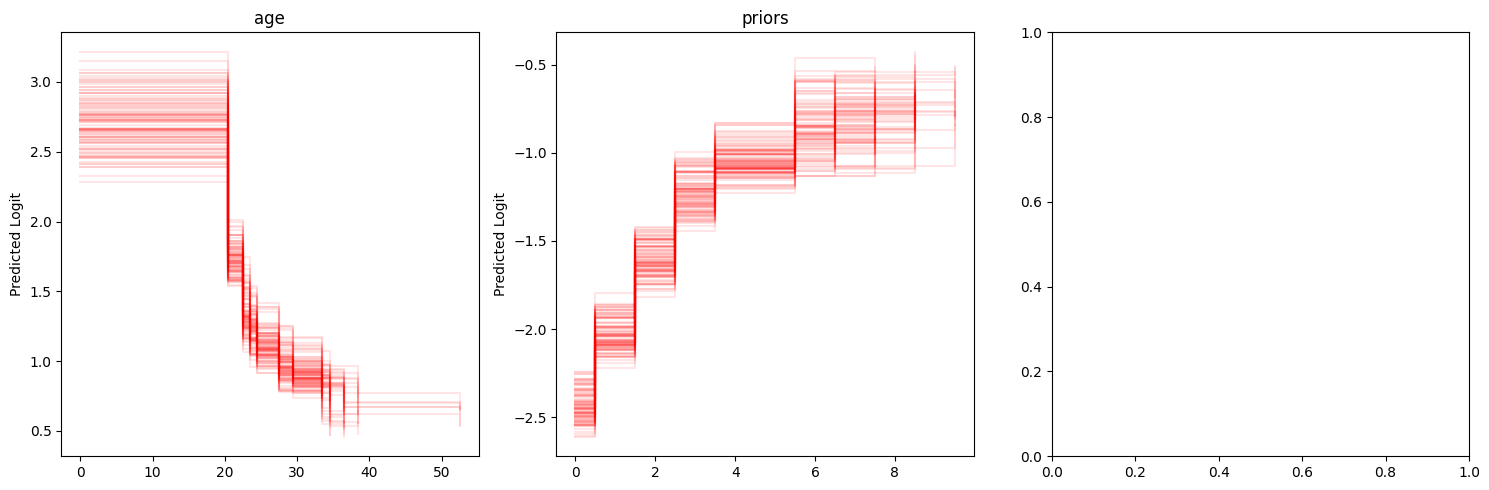

method: swapping


100%|██████████| 100/100 [00:00<00:00, 15810.26it/s]


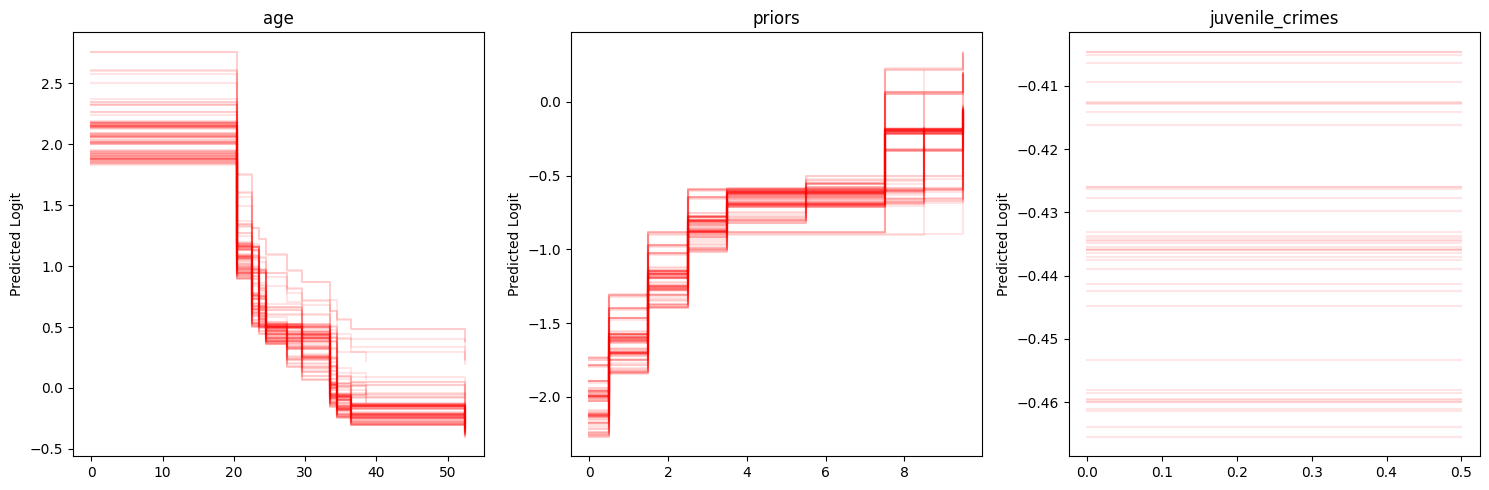

In [21]:
show_gam(all_datasets_results, 'compas')

method: uniform_ellipsoid_sampling


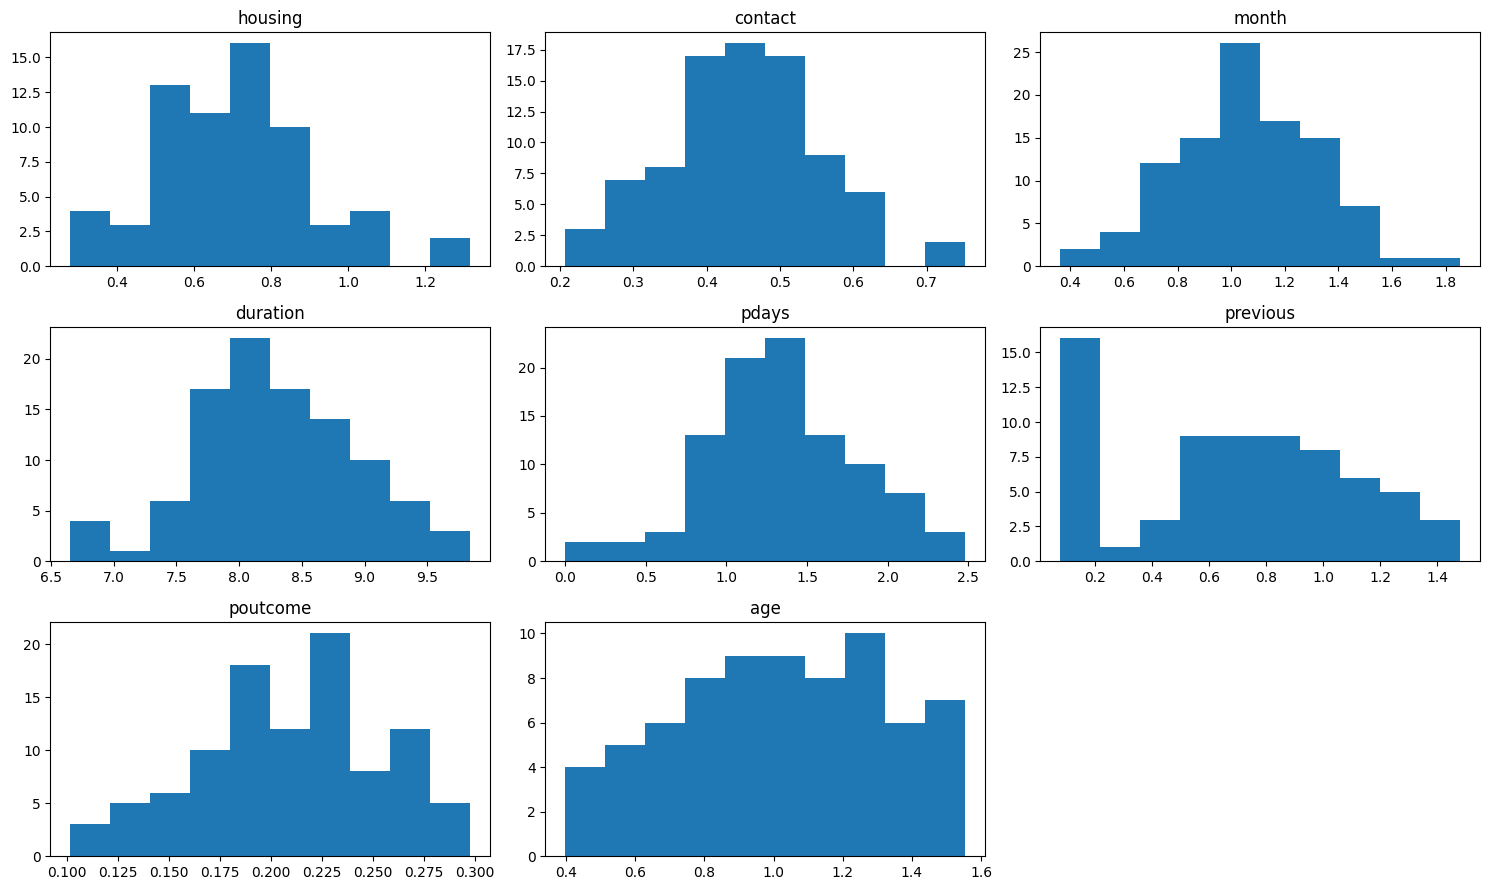

method: poisson_False_ellipsoid_sampling


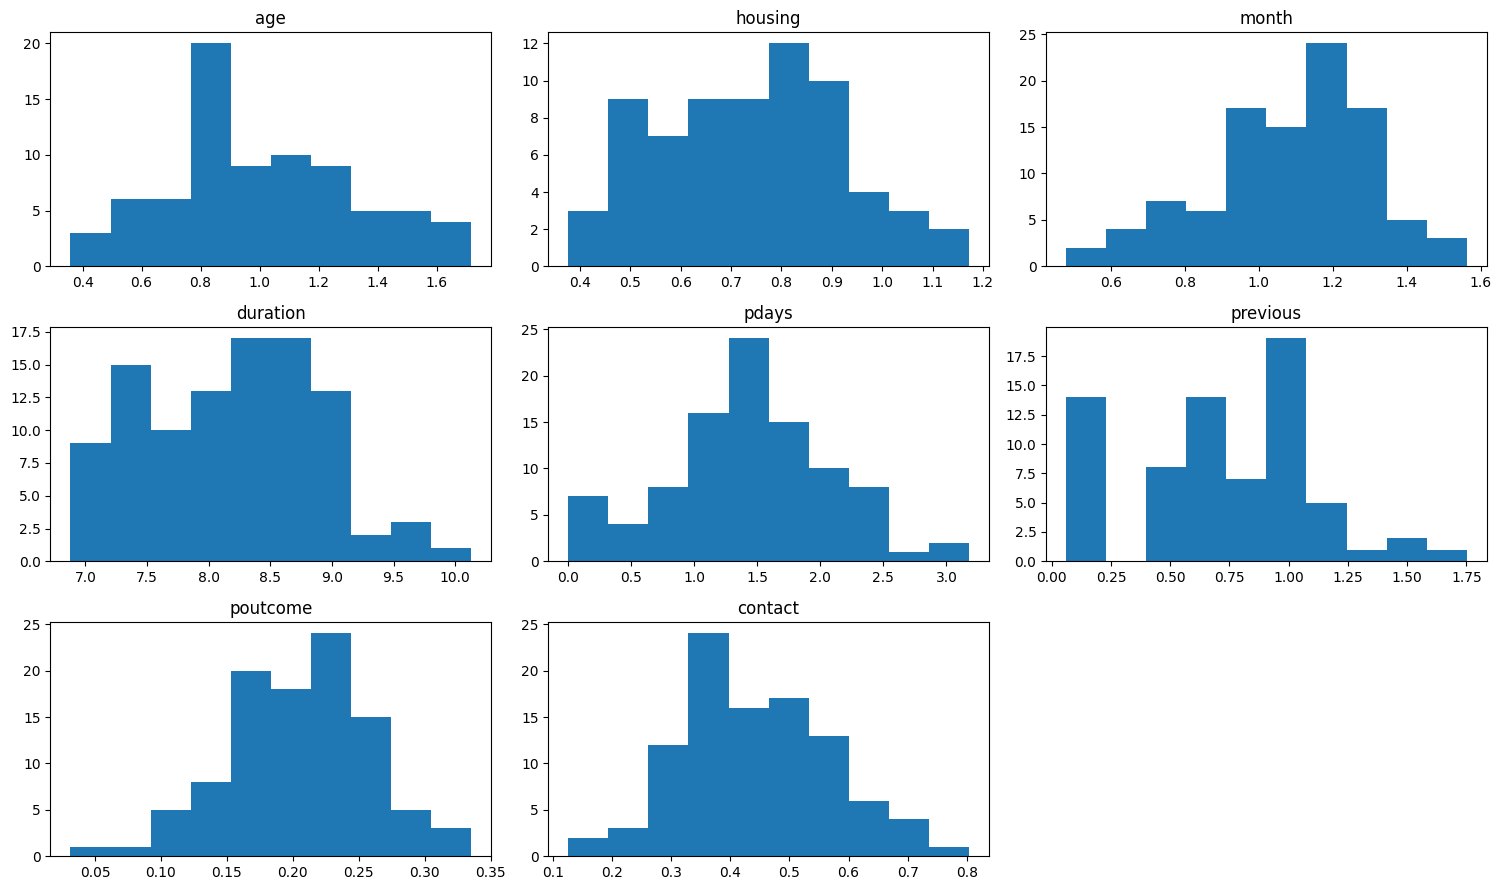

method: poisson_True_ellipsoid_sampling


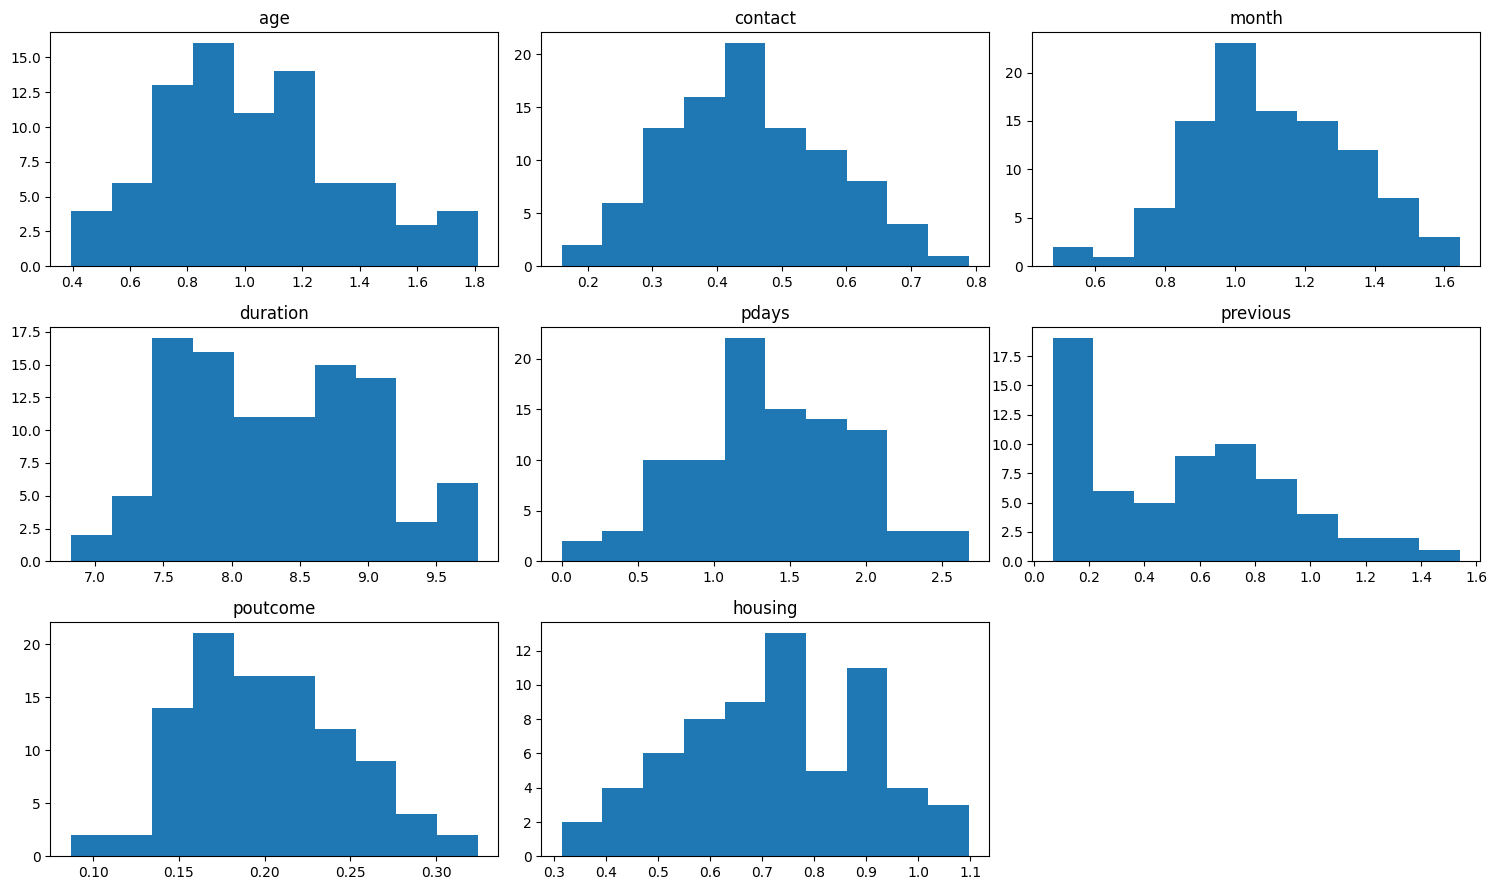

method: permutation_False_ellipsoid_sampling


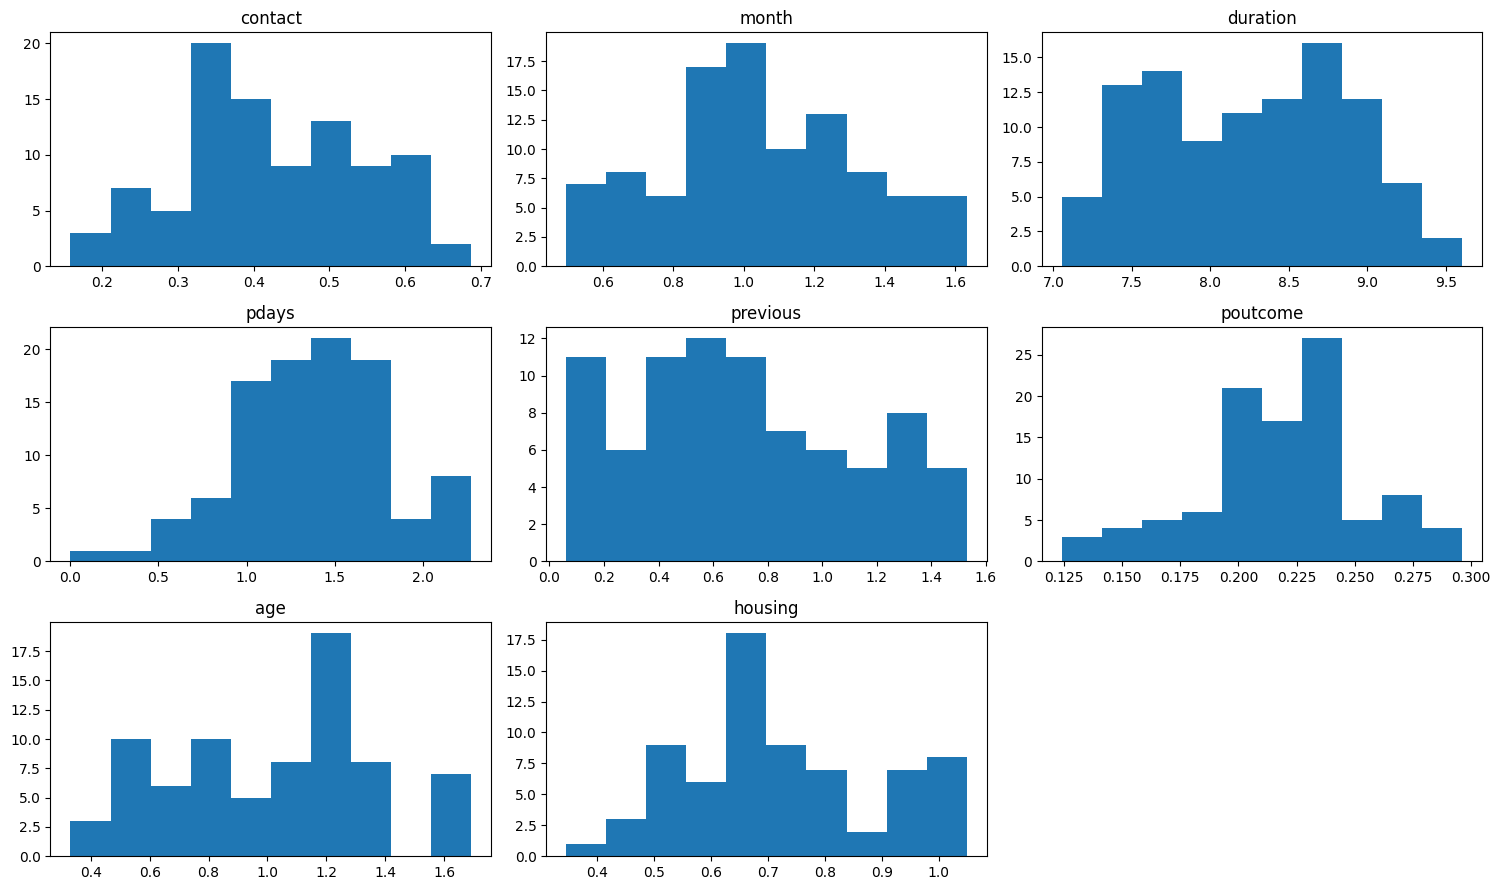

method: permutation_True_ellipsoid_sampling


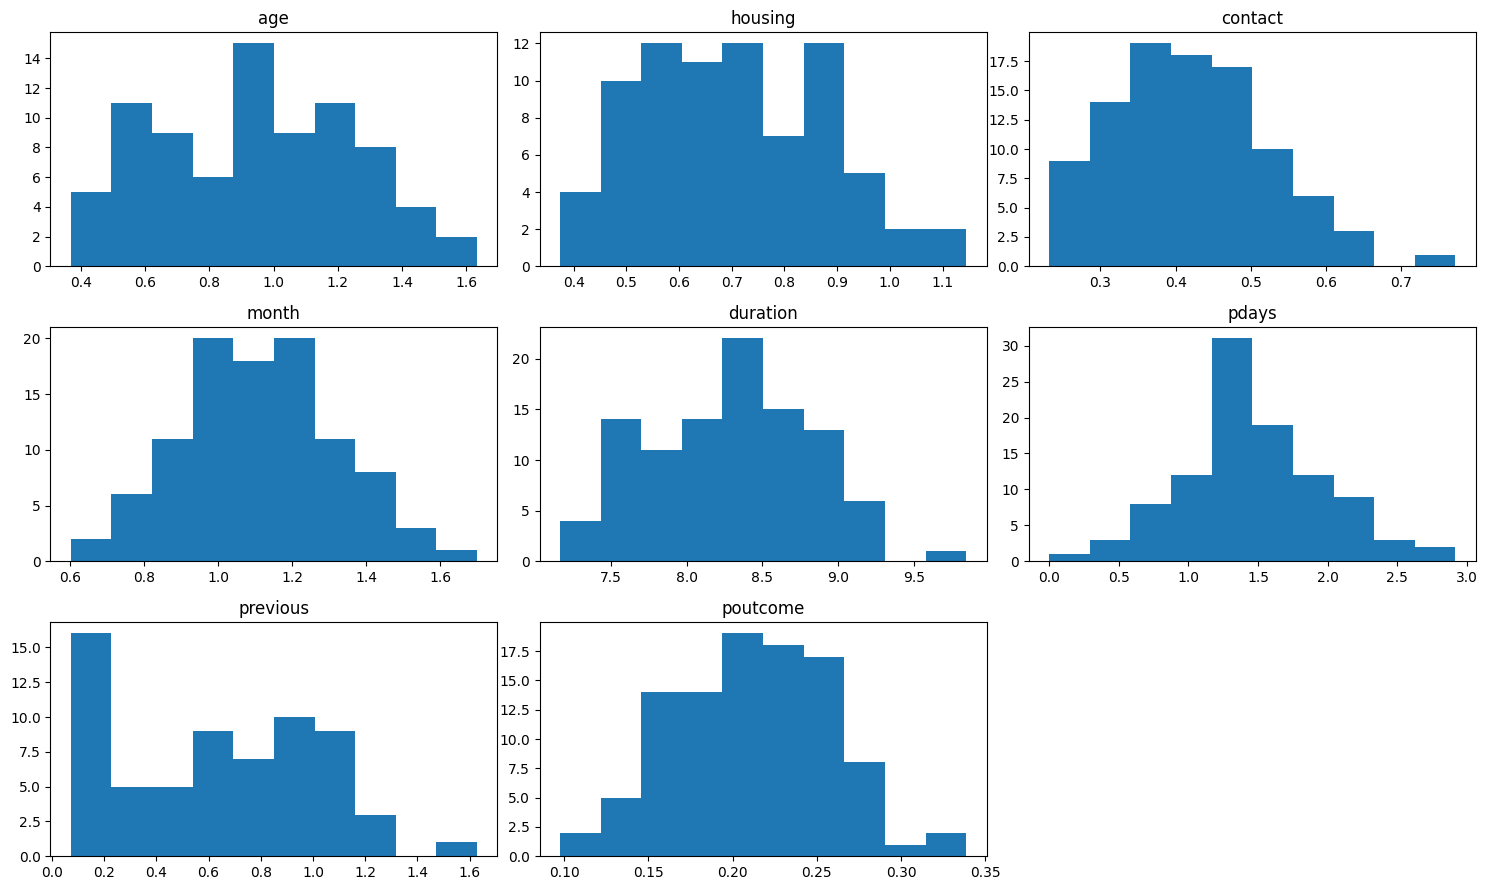

method: blocking


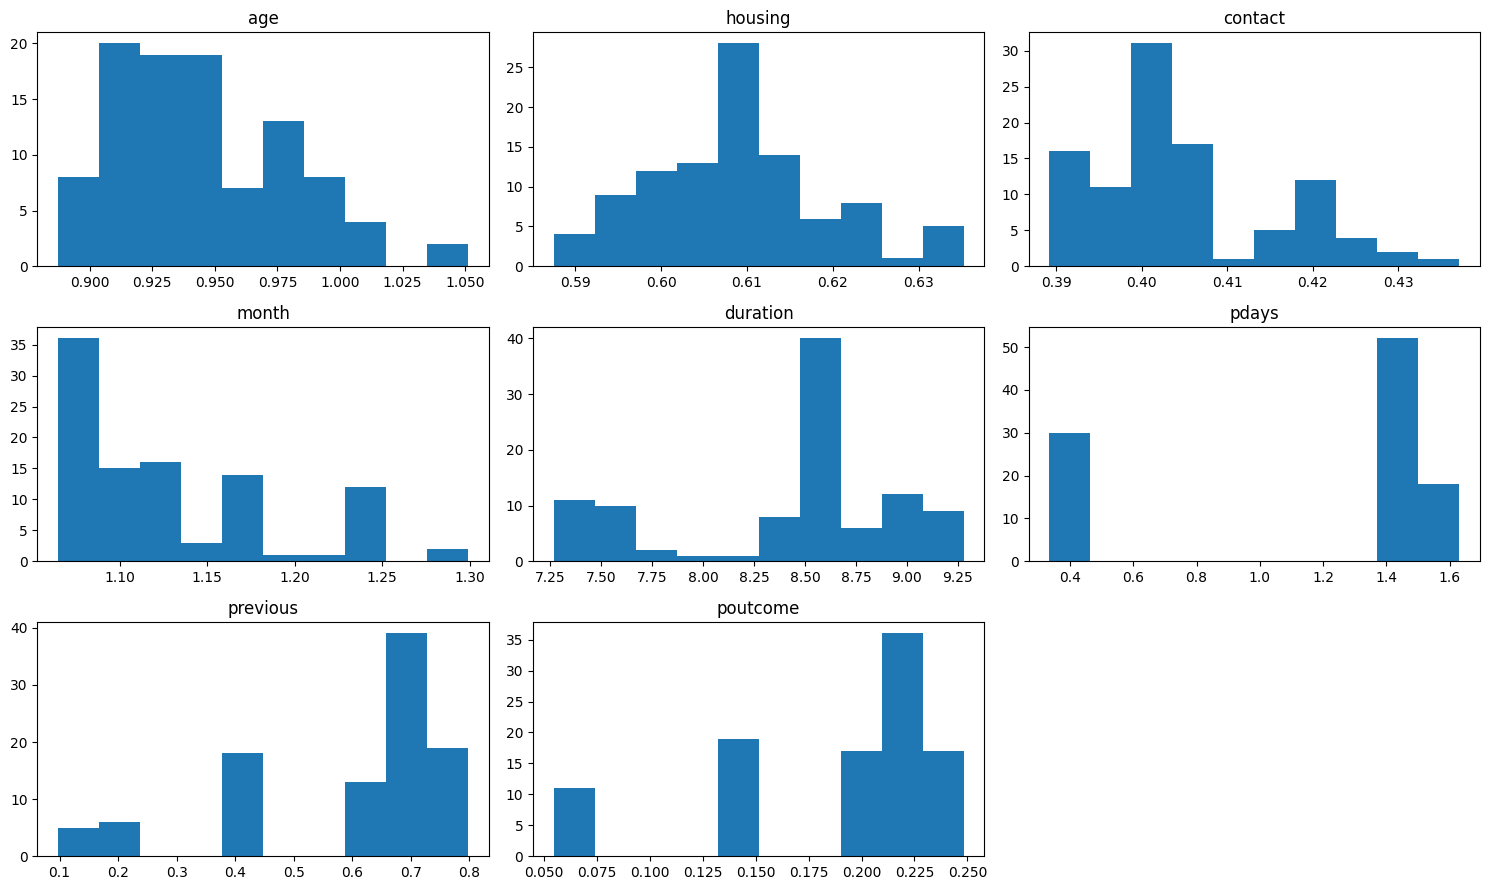

method: quadratic_programming


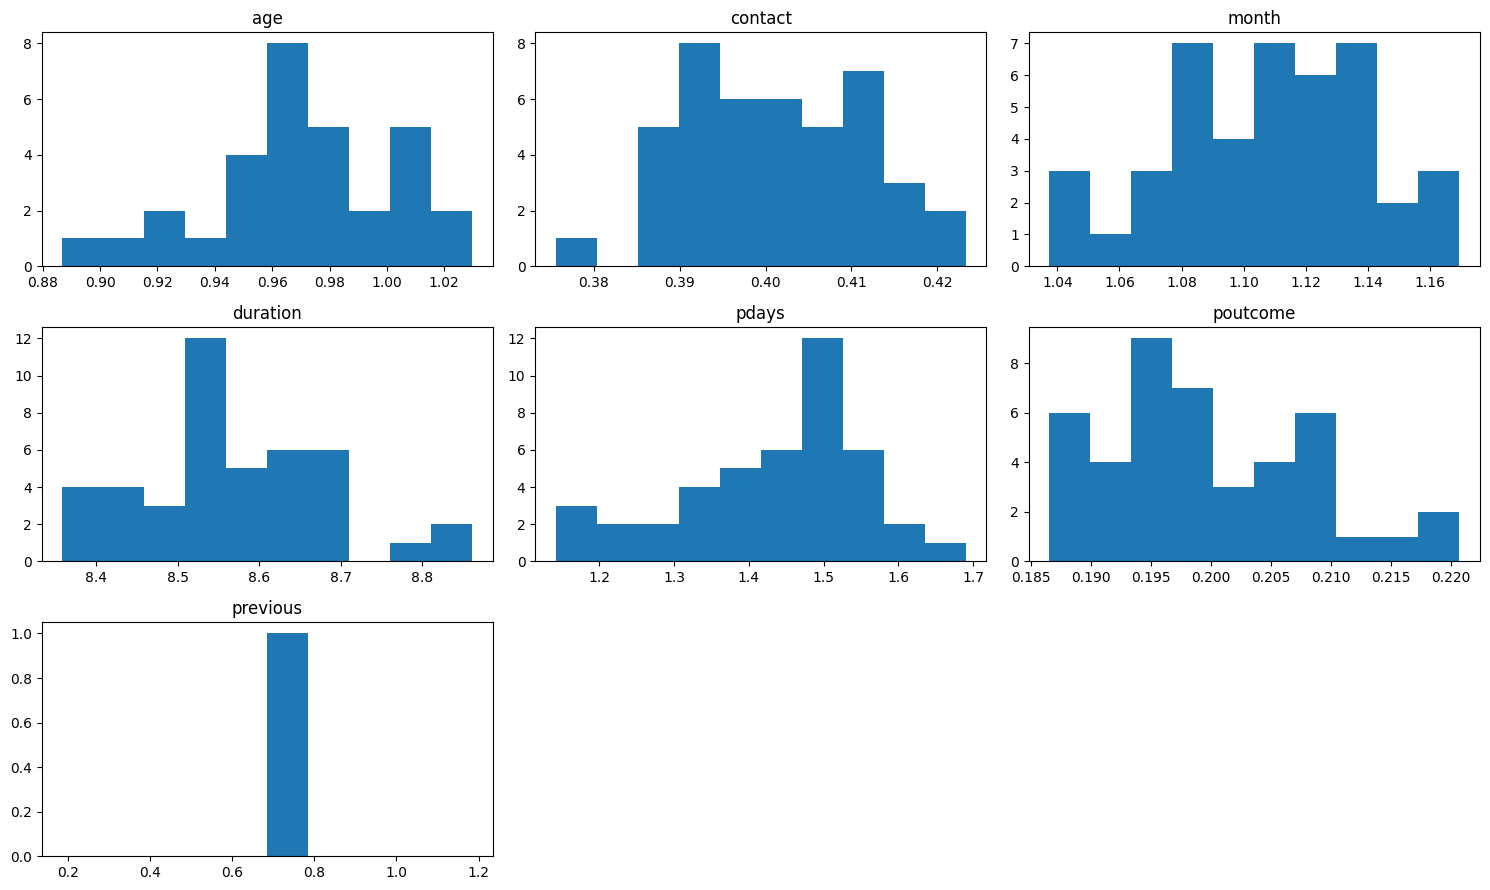

method: swapping


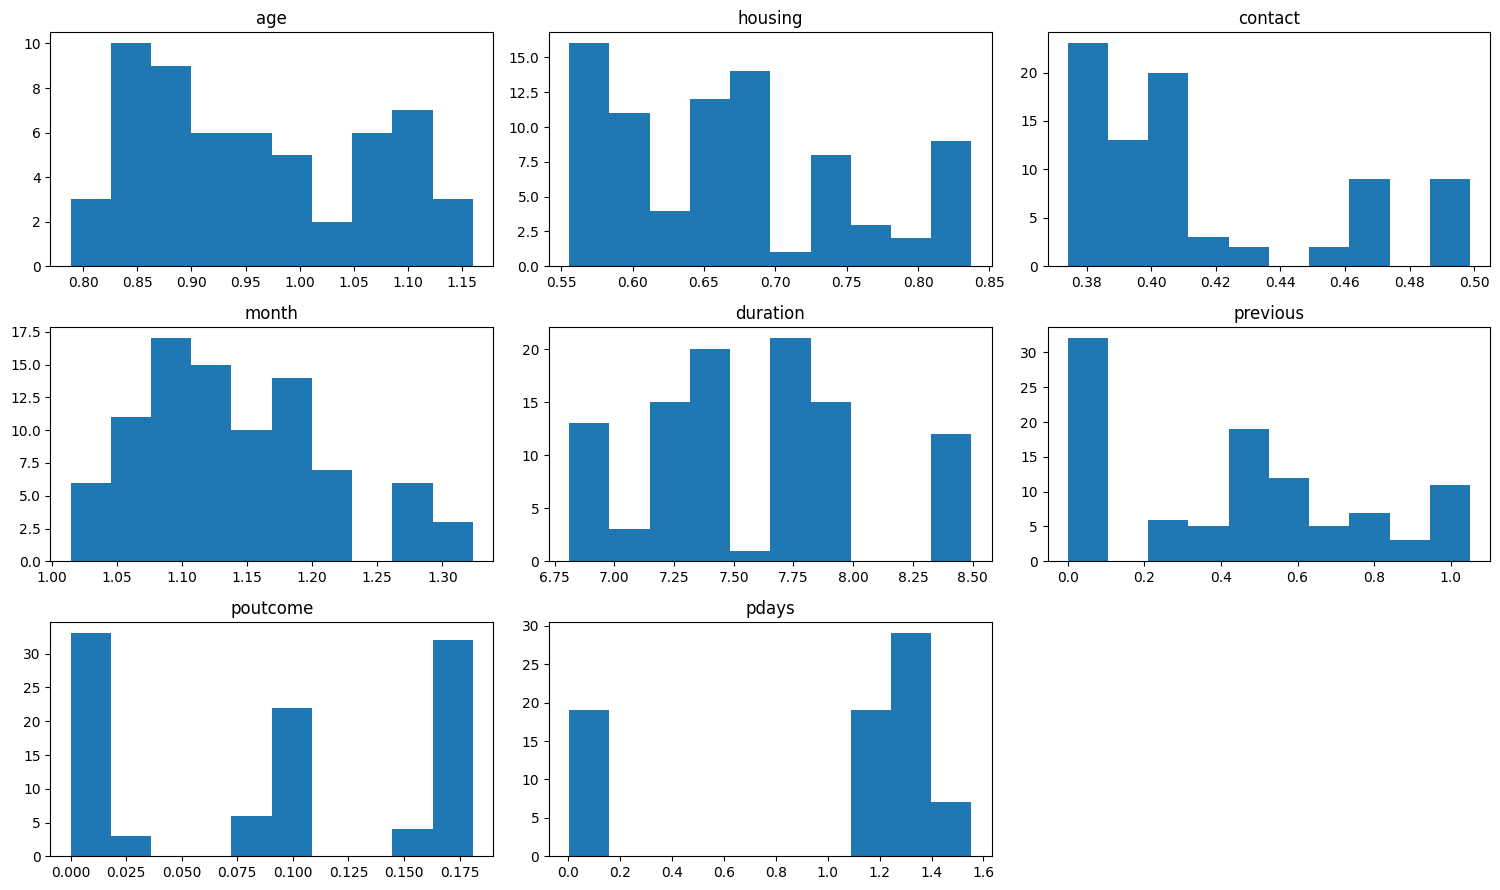

In [22]:
show_variable_importance(all_datasets_results, 'bank')